<img src="images/banner.png" style="width: 100%;">

# Regularization Techniques

**MSDS 2026 | COSCI223: Machine Learning 3**

*Prepared by Kristine Ann M. Carandang*

## Setup

### Modules and Libraries

In [1]:
import os
import numpy as np
import pandas as pd

import keras
from keras import layers
from keras.models import Sequential
from keras import models
from keras import regularizers
from keras.callbacks import EarlyStopping
from tensorflow import data as tf_data

from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 3})

In [2]:
def plot_history(history):
    """Generate the fitting history plot given the history object from
    model training

    Generates the training and validation accuracy and loss plots.

    Parameters
    ----------
    history : keras History object
        History object returned during model fitting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the generated validation and accuracy loss
        plots
    """
    # Get accuracies and losses from history object
    accuracy = history.history['accuracy']
    loss = history.history['loss']
    val_accuracy = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    # Generate epoch number list
    epochs = range(1, len(accuracy) + 1)

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot epochs and accuracy/loss values
    axes[0].plot(epochs, accuracy, 'o', color='tab:blue',
                 label='Train Accuracy')
    axes[0].plot(epochs, val_accuracy, '--', color='tab:blue',
                 label='Validation Accuracy')
    axes[1].plot(epochs, loss, 'o', color='tab:orange', label='Train Loss')
    axes[1].plot(epochs, val_loss, '--', color='tab:orange',
                 label='Validation Loss')

    # Add axis labels and legends
    for ax in axes:
        ax.set_xlabel("Epochs")
        ax.legend()
    axes[0].set_ylabel("Accuracy")
    axes[1].set_ylabel("Loss")
    fig.suptitle("Fitting History Plots", fontsize=16, weight='bold')

    return fig, axes

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

### Cats vs Dogs Dataset

We use this dataset, which is now stored locally under the directory `PetImages`. 

#### Load the dataset

In [4]:
# training parameters
batch_size = 128
n_epochs = 25

In [5]:
# Generate a dataset
image_size = (180, 180)

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)


Found 23438 files belonging to 2 classes.
Using 18751 files for training.
Using 4687 files for validation.


**Visualize the data**

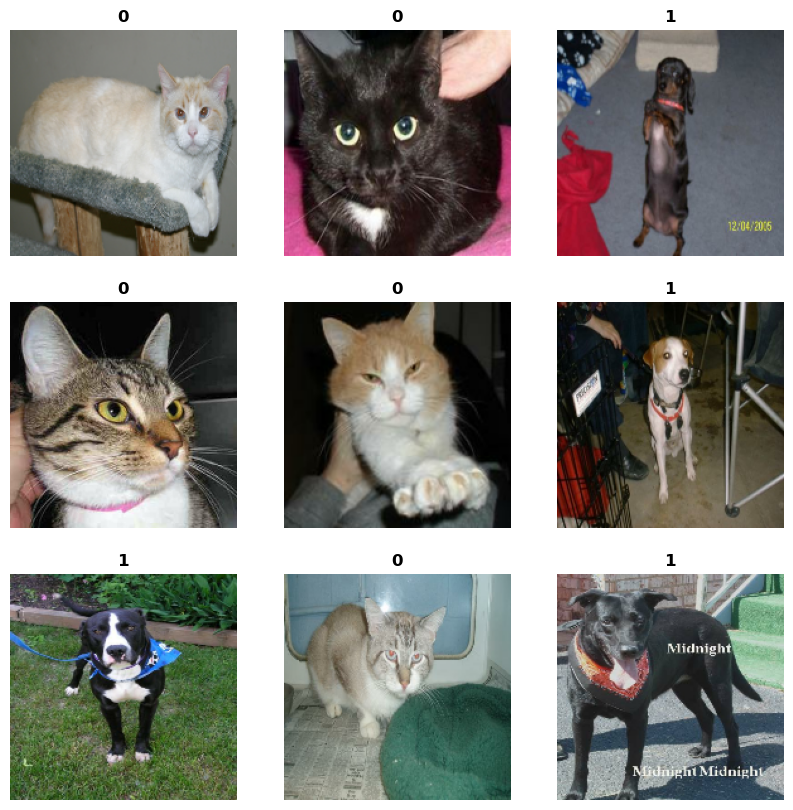

In [6]:
# Visualize the data
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

### Initial Model

In [7]:
# Instantiate an initial CNN model
initial = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Conv2D(32, (3, 3),
                        activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3),
                        activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64,
                 activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1,
                 activation='sigmoid')
])

initial.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 118336)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     7,573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,593,025 (28.97 MB)

 Trainable params: 7,593,025 (28.97 MB)

 Non-trainable params: 0 (0.00 B)

## Altering the training process

### Use `EarlyStopping`

In [8]:
# Perform the model completion step
initial.compile(optimizer='adamax',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Perform model fitting
initial_hx = initial.fit(
    train_ds,
    epochs=n_epochs,
    validation_data=val_ds,
    callbacks=[early_stop]
)

Epoch 1/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 78s 518ms/step - accuracy: 0.5046 - loss: 25.7205 - val_accuracy: 0.4956 - val_loss: 0.6932
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 76s 518ms/step - accuracy: 0.5030 - loss: 0.6931 - val_accuracy: 0.4956 - val_loss: 0.6932
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 75s 508ms/step - accuracy: 0.5030 - loss: 0.6931 - val_accuracy: 0.4956 - val_loss: 0.6932
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 128s 873ms/step - accuracy: 0.5030 - loss: 0.6931 - val_accuracy: 0.4956 - val_loss: 0.6932


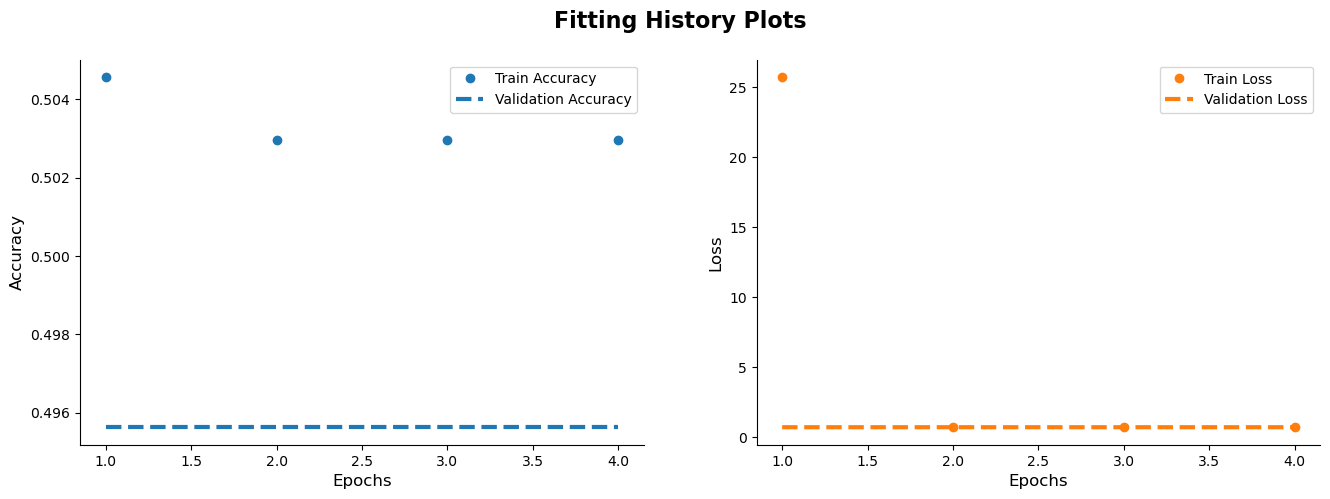

In [9]:
plot_history(initial_hx);

#### Longer patience

In [10]:
longer = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Conv2D(32, (3, 3),
                        activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3),
                        activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64,
                 activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1,
                 activation='sigmoid')
])

# Perform the model completion step
longer.compile(optimizer='adamax',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Perform model fitting
longer_hx = longer.fit(
    train_ds,
    epochs=n_epochs,
    validation_data=val_ds,
    callbacks=[early_stop]
)

Epoch 1/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 71s 473ms/step - accuracy: 0.5820 - loss: 8.8084 - val_accuracy: 0.6187 - val_loss: 0.6473
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 69s 472ms/step - accuracy: 0.6680 - loss: 0.6043 - val_accuracy: 0.6597 - val_loss: 0.6226
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 69s 471ms/step - accuracy: 0.7281 - loss: 0.5353 - val_accuracy: 0.6793 - val_loss: 0.6046
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 70s 473ms/step - accuracy: 0.7805 - loss: 0.4580 - val_accuracy: 0.7049 - val_loss: 0.6002
Epoch 5/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 69s 472ms/step - accuracy: 0.8216 - loss: 0.3854 - val_accuracy: 0.7167 - val_loss: 0.6096
Epoch 6/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 69s 473ms/step - accuracy: 0.8554 - loss: 0.3287 - val_accuracy: 0.7299 - val_loss: 0.5815
Epoch 7/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 71s 484ms/step - accuracy: 0.8797 - loss: 0.2833 - val_accuracy: 0.7201 - val_loss: 0.6242
Epoch 8/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 73s 498ms/step - accuracy: 0.9029 - loss: 0

In [ ]:
plot_history(longer_hx);

### Other callbacks

- [List of Callbacks](https://keras.io/api/callbacks/)
- Intersting to explore:
    - [ReduceLROnPlateau](https://keras.io/api/callbacks/reduce_lr_on_plateau/)
    - [LearningRateScheduler](https://keras.io/api/callbacks/learning_rate_scheduler/)

<div class="alert alert-block alert-info"> 
<b>EXPLORATION TASK</b>
<br>
In your subsequent model trainings, try to incorporate the other callbacks apart from the `EarlyStopping` callback.
<br>
</div>

## Saving the best model

You may use the *`ModelCheckpoint`* callback to save the best model.

In [ ]:
checkpoint_filepath = '/tmp/ckpt/checkpoint.model.keras'
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

# References

- Chollet, F., & Chollet, F. (2021). Deep learning with Python. simon and schuster.
- Bishop, C. M., & Bishop, H. (2023). Deep learning: Foundations and concepts. Springer Nature.
- Goodfellow, I., Bengio, Y., Courville, A., & Bengio, Y. (2016). Deep learning (Vol. 1, No. 2, pp. 1-800). Cambridge: MIT press.
- LeCun et al. (1989). Backpropagation Applied to Handwritten Zip Code Recognition. *Neural Computation* 1(4), pp. 541-551. doi: 10.1162/neco.1989.1.4.541.
- Monterola, CM. ML3 Notebook 2A.
- Simon, J. D. (2024). Understanding Deep Learning.

<img src="images/banner-down.png" style="width: 100%;">